<a href="https://colab.research.google.com/github/Mithu06-dev/AIML_Project/blob/main/Overall_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully
Rows: 649
Columns: 33

CLASSIFICATION MODELS
Logistic Regression Accuracy: 90.77 %
KNN Accuracy: 89.23 %
SVM Accuracy: 90.0 %
Naive Bayes Accuracy: 90.77 %
K-Means Accuracy: 38.46 %
K-Means Silhouette Score: 0.3141

CLASSIFICATION MODEL COMPARISON
Logistic Regression : 90.77 %
KNN : 89.23 %
SVM : 90.0 %
Naive Bayes : 90.77 %
K-Means : 38.46 %

BEST CLASSIFICATION MODEL: Logistic Regression
Accuracy: 90.77 %


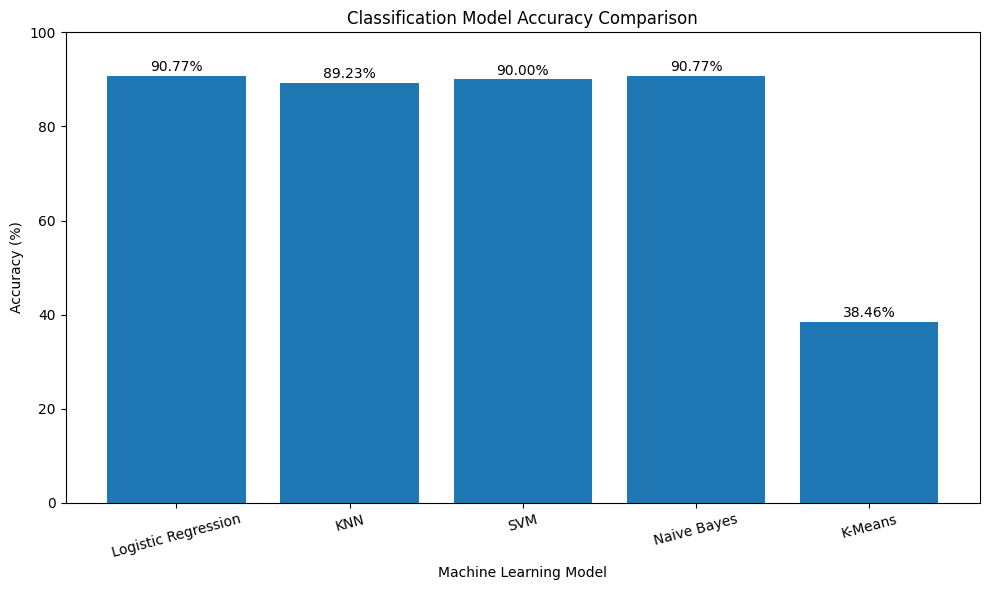


REGRESSION MODELS

REGRESSION MODEL COMPARISON
Linear Regression | R2: 0.8593 | MAE: 0.7477 | RMSE: 1.1714
Decision Tree | R2: 0.8434 | MAE: 0.7536 | RMSE: 1.2359
Random Forest | R2: 0.7977 | MAE: 0.8307 | RMSE: 1.4047
Lasso Regression | R2: 0.8654 | MAE: 0.7097 | RMSE: 1.1458
Ridge Regression | R2: 0.8592 | MAE: 0.7477 | RMSE: 1.1718

BEST REGRESSION MODEL: Lasso Regression
R2 Score: 0.8654


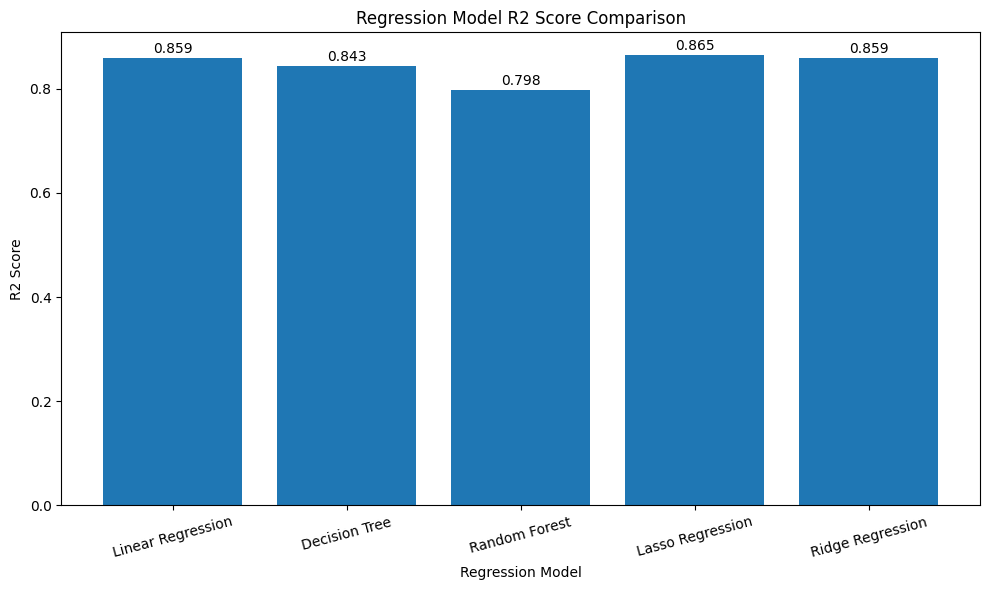

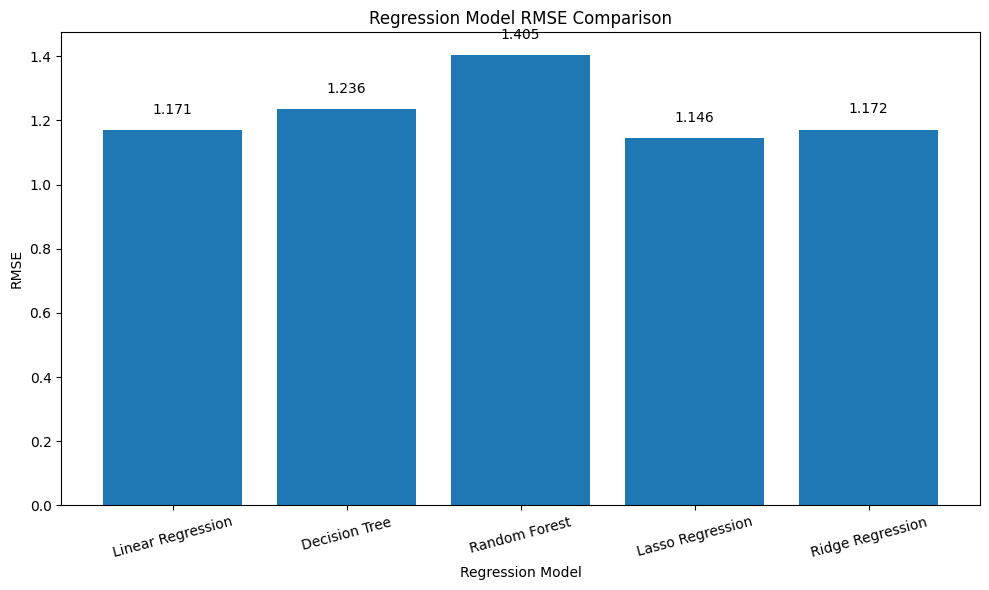


FINAL SUMMARY

BEST CLASSIFICATION MODEL:
Logistic Regression -> 90.77 %

BEST REGRESSION MODEL:
Lasso Regression -> R2: 0.8654

K-MEANS:
Accuracy: 38.46 %
Silhouette Score: 0.3141


In [2]:
# ============================================================
# STUDENT PERFORMANCE - COMPLETE ML MODEL COMPARISON
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Clustering
from sklearn.cluster import KMeans

# Regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("student-por.csv", sep=",")

print("Dataset Loaded Successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()


# ============================================================
# 2. CREATE PASS / FAIL TARGET
# ============================================================

# G3 >= 10 -> Pass
# G3 < 10  -> Fail

df["Pass"] = (df["G3"] >= 10).astype(int)


# ============================================================
# 3. FEATURES
# ============================================================

features = [
    "studytime",
    "absences",
    "G1",
    "G2"
]

X = df[features]

# Classification target
y_class = df["Pass"]

# Regression target
y_reg = df["G3"]


# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_class_train, y_class_test = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)


# ============================================================
# 5. SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# PART A - CLASSIFICATION MODELS
# ============================================================

print("=" * 60)
print("CLASSIFICATION MODELS")
print("=" * 60)


classification_results = {}


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression()

logistic_model.fit(
    X_train_scaled,
    y_class_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_class_test,
    logistic_pred
)

classification_results["Logistic Regression"] = (
    logistic_accuracy * 100
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)


# ============================================================
# 7. KNN
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_class_train
)

knn_pred = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_class_test,
    knn_pred
)

classification_results["KNN"] = (
    knn_accuracy * 100
)

print(
    "KNN Accuracy:",
    round(knn_accuracy * 100, 2),
    "%"
)


# ============================================================
# 8. SVM
# ============================================================

svm_model = SVC(
    kernel="linear"
)

svm_model.fit(
    X_train_scaled,
    y_class_train
)

svm_pred = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_class_test,
    svm_pred
)

classification_results["SVM"] = (
    svm_accuracy * 100
)

print(
    "SVM Accuracy:",
    round(svm_accuracy * 100, 2),
    "%"
)


# ============================================================
# 9. NAIVE BAYES
# ============================================================

nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_class_train
)

nb_pred = nb_model.predict(
    X_test_scaled
)

nb_accuracy = accuracy_score(
    y_class_test,
    nb_pred
)

classification_results["Naive Bayes"] = (
    nb_accuracy * 100
)

print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy * 100, 2),
    "%"
)


# ============================================================
# 10. K-MEANS
# ============================================================

kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Train K-Means
kmeans_model.fit(
    X_train_scaled
)

# Training clusters
train_clusters = kmeans_model.predict(
    X_train_scaled
)

# Test clusters
test_clusters = kmeans_model.predict(
    X_test_scaled
)


# ------------------------------------------------------------
# Map clusters to Pass / Fail
# ------------------------------------------------------------

cluster_0_pass_rate = y_class_train[
    train_clusters == 0
].mean()

cluster_1_pass_rate = y_class_train[
    train_clusters == 1
].mean()


if cluster_0_pass_rate > cluster_1_pass_rate:

    kmeans_pred = test_clusters

else:

    kmeans_pred = 1 - test_clusters


# K-Means external accuracy
kmeans_accuracy = accuracy_score(
    y_class_test,
    kmeans_pred
)

# Silhouette score
kmeans_silhouette = silhouette_score(
    X_test_scaled,
    test_clusters
)

classification_results["K-Means"] = (
    kmeans_accuracy * 100
)

print(
    "K-Means Accuracy:",
    round(kmeans_accuracy * 100, 2),
    "%"
)

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)


# ============================================================
# 11. CLASSIFICATION RESULTS
# ============================================================

print()
print("=" * 60)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 60)

for model, score in classification_results.items():

    print(
        model,
        ":",
        round(score, 2),
        "%"
    )


# Best classification model
best_classification = max(
    classification_results,
    key=classification_results.get
)

print()
print(
    "BEST CLASSIFICATION MODEL:",
    best_classification
)

print(
    "Accuracy:",
    round(
        classification_results[best_classification],
        2
    ),
    "%"
)


# ============================================================
# 12. CLASSIFICATION GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

models = list(
    classification_results.keys()
)

scores = list(
    classification_results.values()
)

bars = plt.bar(
    models,
    scores
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Classification Model Accuracy Comparison")

plt.ylim(0, 100)

for bar, score in zip(bars, scores):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        bar.get_height() + 1,
        f"{score:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()


# ============================================================
# PART B - REGRESSION MODELS
# ============================================================

print()
print("=" * 60)
print("REGRESSION MODELS")
print("=" * 60)


# ============================================================
# 13. REGRESSION TRAIN TEST SPLIT
# ============================================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = (
    train_test_split(
        X,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)


# Scale for linear models
X_train_reg_scaled = scaler.fit_transform(
    X_train_reg
)

X_test_reg_scaled = scaler.transform(
    X_test_reg
)


# Store results

regression_r2 = {}
regression_mae = {}
regression_rmse = {}


# ============================================================
# 14. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

linear_pred = linear_model.predict(
    X_test_reg_scaled
)

linear_r2 = r2_score(
    y_test_reg,
    linear_pred
)

linear_mae = mean_absolute_error(
    y_test_reg,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        linear_pred
    )
)

regression_r2["Linear Regression"] = linear_r2
regression_mae["Linear Regression"] = linear_mae
regression_rmse["Linear Regression"] = linear_rmse


# ============================================================
# 15. DECISION TREE REGRESSION
# ============================================================

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train_reg,
    y_train_reg
)

tree_pred = tree_model.predict(
    X_test_reg
)

tree_r2 = r2_score(
    y_test_reg,
    tree_pred
)

tree_mae = mean_absolute_error(
    y_test_reg,
    tree_pred
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        tree_pred
    )
)

regression_r2["Decision Tree"] = tree_r2
regression_mae["Decision Tree"] = tree_mae
regression_rmse["Decision Tree"] = tree_rmse


# ============================================================
# 16. RANDOM FOREST REGRESSION
# ============================================================

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(
    X_train_reg,
    y_train_reg
)

forest_pred = forest_model.predict(
    X_test_reg
)

forest_r2 = r2_score(
    y_test_reg,
    forest_pred
)

forest_mae = mean_absolute_error(
    y_test_reg,
    forest_pred
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        forest_pred
    )
)

regression_r2["Random Forest"] = forest_r2
regression_mae["Random Forest"] = forest_mae
regression_rmse["Random Forest"] = forest_rmse


# ============================================================
# 17. LASSO REGRESSION
# ============================================================

lasso_model = Lasso(
    alpha=0.1
)

lasso_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

lasso_pred = lasso_model.predict(
    X_test_reg_scaled
)

lasso_r2 = r2_score(
    y_test_reg,
    lasso_pred
)

lasso_mae = mean_absolute_error(
    y_test_reg,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        lasso_pred
    )
)

regression_r2["Lasso Regression"] = lasso_r2
regression_mae["Lasso Regression"] = lasso_mae
regression_rmse["Lasso Regression"] = lasso_rmse


# ============================================================
# 18. RIDGE REGRESSION
# ============================================================

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

ridge_pred = ridge_model.predict(
    X_test_reg_scaled
)

ridge_r2 = r2_score(
    y_test_reg,
    ridge_pred
)

ridge_mae = mean_absolute_error(
    y_test_reg,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        ridge_pred
    )
)

regression_r2["Ridge Regression"] = ridge_r2
regression_mae["Ridge Regression"] = ridge_mae
regression_rmse["Ridge Regression"] = ridge_rmse


# ============================================================
# 19. DISPLAY REGRESSION RESULTS
# ============================================================

print()
print("=" * 60)
print("REGRESSION MODEL COMPARISON")
print("=" * 60)

for model in regression_r2:

    print(
        model,
        "| R2:",
        round(regression_r2[model], 4),
        "| MAE:",
        round(regression_mae[model], 4),
        "| RMSE:",
        round(regression_rmse[model], 4)
    )


# ============================================================
# 20. BEST REGRESSION MODEL
# ============================================================

best_regression = max(
    regression_r2,
    key=regression_r2.get
)

print()
print(
    "BEST REGRESSION MODEL:",
    best_regression
)

print(
    "R2 Score:",
    round(
        regression_r2[best_regression],
        4
    )
)


# ============================================================
# 21. R2 COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

models = list(
    regression_r2.keys()
)

sccores = list(
    regression_r2.values()
)

bars = plt.bar(
    models,
    sccores
)

plt.xlabel("Regression Model")
plt.ylabel("R2 Score")

plt.title(
    "Regression Model R2 Score Comparison"
)

for bar, score in zip(bars, sccores):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.3f}",
        ha="center"
    )

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()


# ============================================================
# 22. RMSE COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

models = list(
    regression_rmse.keys()
)

scores = list(
    regression_rmse.values()
)

bars = plt.bar(
    models,
    scores
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")

plt.title(
    "Regression Model RMSE Comparison"
)

for bar, score in zip(bars, scores):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{score:.3f}",
        ha="center"
    )

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()


# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print()
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print()
print("BEST CLASSIFICATION MODEL:")
print(
    best_classification,
    "->",
    round(
        classification_results[best_classification],
        2
    ),
    "%"
)

print()
print("BEST REGRESSION MODEL:")
print(
    best_regression,
    "-> R2:",
    round(
        regression_r2[best_regression],
        4
    )
)

print()
print("K-MEANS:")
print(
    "Accuracy:",
    round(
        kmeans_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Silhouette Score:",
    round(
        kmeans_silhouette,
        4
    )
)